In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================

import os, re, cv2, copy, time, random, gc, math, hashlib, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42

USE_AMP   = torch.cuda.is_available()
AMP_DTYPE = torch.float16 if USE_AMP else torch.float32

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = True       # ⚡ faster convolutions

seed_everything(SEED)
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

Device: cuda | AMP: True


In [2]:
# ============================================================
# CELL 2: CONFIGURATION (⚡ tuned for speed + accuracy)
# ============================================================

class CFG:
    data_root     = "/teamspace/studios/this_studio/EndoscopicBladderTissue"
    aug_root      = "/teamspace/studios/this_studio/Augmented Data"
    aug_manifest  = "/teamspace/studios/this_studio/Augmented Data/augmented_only_manifest.csv"

    # ⚡ Feature cache — avoids re-extraction on re-runs
    cache_dir     = "feature_cache"

    class_names   = ['HGC', 'LGC', 'Normal']
    num_classes   = 3

    # Preprocessing
    image_resize  = 512
    clahe_clip    = 1.5
    clahe_grid    = (16, 16)

    # Multi-scale patches — ⚡ reduced max_patches for speed
    patch_scales        = [96, 128, 192]
    patch_output_size   = 224
    patch_stride_frac   = 0.5
    min_tissue          = 0.45
    max_bright          = 245
    min_bright          = 15
    min_sat             = 10
    min_focus           = 8.0
    top_quality_frac    = 0.75
    max_patches_per_image = 50          # ⚡ was 80

    # Feature extraction — ⚡ bigger batches
    feat_batch    = 64                  # ⚡ was 32
    feat_dim      = 1024

    # CLAM — ⚡ improved architecture params
    mil_hidden    = 512
    mil_dropout   = 0.25               # ⚡ slightly higher
    clam_k_sample = 10                 # ⚡ was 12
    feat_noise_std = 0.03
    feat_drop_p   = 0.1
    inst_loss_w   = 0.3
    bag_loss_w    = 1.0
    label_smooth  = 0.05              # ⚡ NEW

    # Training — ⚡ tighter schedule
    epochs        = 75                 # ⚡ was 100
    patience      = 15                 # ⚡ was 25
    lr            = 1e-4
    wd            = 5e-5
    grad_clip     = 1.0
    max_patches_train = 250            # ⚡ was 400
    max_patches_test  = 400            # ⚡ was 600

    # Ensemble + TTA — ⚡ fewer but better
    n_ensemble    = 3                  # ⚡ was 5
    use_tta       = True
    tta_rounds    = 3                  # ⚡ was 5

    class_weights = None

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

LABEL_MAP = {'HGC': 'HGC', 'LGC': 'LGC', 'NST': 'Normal', 'NTL': 'Normal'}

os.makedirs(CFG.cache_dir, exist_ok=True)
print("✓ Config loaded (optimised)")

✓ Config loaded (optimised)


In [3]:
# ============================================================
# CELL 3: LOAD ORIGINAL DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING ORIGINAL DATASET")
print("="*60)

records   = []
pattern   = re.compile(r'pt[_]?0*(\d+)')

for label in os.listdir(CFG.data_root):
    class_path = os.path.join(CFG.data_root, label)
    if not os.path.isdir(class_path):
        continue
    if label not in LABEL_MAP:
        print(f"  ⚠ Skipping unknown folder: {label}")
        continue
    for img_name in os.listdir(class_path):
        match = pattern.search(img_name)
        if match:
            records.append({
                "path":           os.path.join(class_path, img_name),
                "label":          LABEL_MAP[label],
                "original_label": label,
                "patient":        int(match.group(1)),
                "filename":       img_name,
                "is_augmented":   False,
                "aug_mode":       "none",
            })

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)

print(f"Total original images : {len(df)}")
print(f"Total patients        : {df.patient.nunique()}")
print(f"Classes               : {CFG.class_names}")

class_counts = df['label'].value_counts()
total = len(df)
print(f"\nClass distribution:")
for cls in CFG.class_names:
    n = class_counts.get(cls, 0)
    print(f"  {cls}: {n} ({100*n/total:.1f}%)")

PATIENTS   = sorted(df.patient.unique())
N_PATIENTS = len(PATIENTS)

print(f"\n{'Patient':<10} {'#Imgs':<8} {'Distribution'}")
print("-"*65)
for pid in PATIENTS:
    pdf    = df[df.patient == pid]
    counts = Counter(pdf.label.values)
    dist   = ", ".join(f"{k}:{v}" for k, v in sorted(counts.items()))
    print(f"  P{pid:<8} {len(pdf):<8} {dist}")

print(f"\n✓ {N_PATIENTS} patients, {len(df)} original images")


LOADING ORIGINAL DATASET
Total original images : 1607
Total patients        : 14
Classes               : ['HGC', 'LGC', 'Normal']

Class distribution:
  HGC: 426 (26.5%)
  LGC: 595 (37.0%)
  Normal: 586 (36.5%)

Patient    #Imgs    Distribution
-----------------------------------------------------------------
  P1        468      HGC:81, LGC:118, Normal:269
  P2        283      HGC:67, LGC:104, Normal:112
  P3        160      HGC:92, LGC:24, Normal:44
  P4        220      HGC:103, LGC:72, Normal:45
  P5        162      HGC:38, LGC:66, Normal:58
  P6        115      HGC:37, LGC:72, Normal:6
  P7        27       HGC:8, LGC:13, Normal:6
  P8        51       LGC:39, Normal:12
  P9        6        LGC:6
  P10       47       LGC:47
  P11       44       LGC:10, Normal:34
  P12       18       LGC:18
  P13       3        LGC:3
  P14       3        LGC:3

✓ 14 patients, 1607 original images


In [4]:
# ============================================================
# CELL 4: LOAD AUGMENTED DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING AUGMENTED DATASET")
print("="*60)

aug_df = pd.read_csv(CFG.aug_manifest)

print(f"Manifest rows    : {len(aug_df)}")
print(f"Manifest columns : {aug_df.columns.tolist()}")
print(f"\nFirst row sample:")
print(aug_df.iloc[0].to_dict())

# Build filename → path index
print("\nBuilding file index from disk...")
aug_file_index = {}
for root, dirs, files in os.walk(CFG.aug_root):
    for fname in files:
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            aug_file_index[fname] = os.path.join(root, fname)

print(f"Indexed {len(aug_file_index)} image files from disk")

# Identify filename column
FNAME_COL = None
for candidate in ['HLY', 'filename', 'aug_filename', 'file']:
    if candidate in aug_df.columns:
        FNAME_COL = candidate
        break

if FNAME_COL is None:
    for col in aug_df.columns:
        sample = str(aug_df[col].iloc[0])
        if sample.strip().endswith(('.png', '.jpg', '.jpeg')):
            FNAME_COL = col
            break

if FNAME_COL is None:
    raise ValueError(
        f"Could not find filename column. Columns: {aug_df.columns.tolist()}"
    )

print(f"Using filename column : '{FNAME_COL}'")

def resolve_aug_path(fname):
    fname    = str(fname).strip()
    if fname in aug_file_index:
        return aug_file_index[fname]
    basename = os.path.basename(fname)
    if basename in aug_file_index:
        return aug_file_index[basename]
    return None

aug_df['path'] = aug_df[FNAME_COL].apply(resolve_aug_path)
missing = aug_df['path'].isna().sum()
aug_df  = aug_df[aug_df['path'].notna()].reset_index(drop=True)
print(f"\nResolved : {len(aug_df)} | Missing  : {missing}")

aug_df['label'] = aug_df['tissue type'].map(LABEL_MAP)
unmapped = aug_df['label'].isna().sum()
if unmapped:
    print(f"⚠ Dropping {unmapped} rows with unmapped tissue type")
    aug_df = aug_df[aug_df['label'].notna()].copy()

aug_df['target']       = aug_df['label'].map(class_to_idx)
aug_df['is_augmented'] = True

if 'patient_id' in aug_df.columns:
    aug_df = aug_df.rename(columns={'patient_id': 'patient'})

if 'patient' not in aug_df.columns:
    raise ValueError(f"No patient column. Columns: {aug_df.columns.tolist()}")

aug_df['patient'] = aug_df['patient'].astype(int)

# Quick verification
print("\nVerifying sample files:")
ok, fail = 0, 0
for _, row in aug_df.head(5).iterrows():
    img = cv2.imread(row['path'])
    if img is not None: ok += 1
    else: fail += 1
if fail == 0:
    print(f"  {ok}/5 readable ✓")
else:
    print(f"  {ok}/5 ok, {fail} failed ✗")

print(f"\nAugmented class distribution:")
for cls in CFG.class_names:
    n = (aug_df['label'] == cls).sum()
    print(f"  {cls}: {n}")

print(f"\n✓ {len(aug_df)} augmented images ready")


LOADING AUGMENTED DATASET
Manifest rows    : 1676
Manifest columns : ['HLY', 'tissue type', 'imaging type', 'patient_id', 'is_augmented', 'aug_mode', 'source_filename', 'source_domain', 'source_abs_path', 'aug_abs_path', 'full_path', 'sub_dataset', 'abs_path']

First row sample:
{'HLY': 'case_002_pt_003_frame_0009_WLI2NBI.png', 'tissue type': 'HGC', 'imaging type': 'NBI', 'patient_id': 3, 'is_augmented': True, 'aug_mode': 'WLI2NBI', 'source_filename': 'case_002_pt_003_frame_0009.png', 'source_domain': 'WLI', 'source_abs_path': '/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/HGC/case_002_pt_003_frame_0009.png', 'aug_abs_path': '/kaggle/working/augmented_data/WLI2NBI/HGC/case_002_pt_003_frame_0009_WLI2NBI.png', 'full_path': 'WLI2NBI/HGC/case_002_pt_003_frame_0009_WLI2NBI.png', 'sub_dataset': 'train', 'abs_path': '/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/HGC/case_

In [5]:
# ============================================================
# CELL 5: CLASS WEIGHTS
# ============================================================

weights = []
print(f"\nClass weights (from original data):")
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    w     = total / (CFG.num_classes * max(count, 1))
    weights.append(w)
    print(f"  {cls}: {count} images → weight={w:.3f}")

CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights tensor: {CFG.class_weights}")


Class weights (from original data):
  HGC: 426 images → weight=1.257
  LGC: 595 images → weight=0.900
  Normal: 586 images → weight=0.914
Class weights tensor: tensor([1.2574, 0.9003, 0.9141], device='cuda:0')


In [6]:
# ============================================================
# CELL 6: LAB NORMALIZER + CLAHE
# ============================================================

class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, images_bgr):
        stats = {'L': [], 'a': [], 'b': []}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L', 'a', 'b']):
                stats[ch].append({
                    'm': lab[:, :, i].mean(),
                    's': lab[:, :, i].std() + 1e-6
                })
        self.ref = {
            ch: {
                'm': np.median([s['m'] for s in stats[ch]]),
                's': np.median([s['s'] for s in stats[ch]])
            }
            for ch in ['L', 'a', 'b']
        }
        return self

    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L', 'a', 'b']):
            c  = lab[:, :, i]
            sm, ss = c.mean(), c.std() + 1e-6
            lab[:, :, i] = np.clip(
                (c - sm) * (self.ref[ch]['s'] / ss) + self.ref[ch]['m'],
                0, 255
            )
        lab = lab.astype(np.uint8)
        clahe = cv2.createCLAHE(
            clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid
        )
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    s    = CFG.image_resize / max(h, w)
    if s != 1:
        img = cv2.resize(img, (int(w * s), int(h * s)),
                         interpolation=cv2.INTER_AREA)
    if norm:
        img = norm.transform(img)
    return img


def fit_normalizer_excluding(exclude_pid=None):
    samples = []
    for pid in PATIENTS:
        if pid == exclude_pid:
            continue
        for fp in df[df.patient == pid].path.values[:12]:
            try:
                img = cv2.imread(fp)
                if img is not None:
                    h, w = img.shape[:2]
                    s    = CFG.image_resize / max(h, w)
                    if s != 1:
                        img = cv2.resize(img, (int(w * s), int(h * s)))
                    samples.append(img)
            except:
                pass
    return LabNormalizer().fit(samples)


global_normalizer = fit_normalizer_excluding(exclude_pid=None)
print("✓ Global normalizer fitted")

✓ Global normalizer fitted


In [7]:
# ============================================================
# CELL 7: MULTI-SCALE PATCH EXTRACTION (⚡ optimised)
# ============================================================

def compute_quality(patch_bgr):
    """⚡ Early-exit quality filter — rejects bad patches faster."""
    hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    v   = hsv[:, :, 2].astype(np.float32)
    s   = hsv[:, :, 1].astype(np.float32)

    mask        = (v < CFG.max_bright) & (v > CFG.min_bright) & (s > CFG.min_sat)
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG.min_tissue:
        return -1.0                        # ⚡ early exit

    gray  = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG.min_focus:
        return -1.0                        # ⚡ early exit

    focus_norm  = min(focus / 100.0, 1.0)
    sat_std     = s[mask].std() / 50.0 if mask.sum() > 10 else 0
    sat_norm    = min(sat_std, 1.0)
    edges       = cv2.Canny(gray, 50, 150)
    edge_density = min(edges.sum() / (255.0 * edges.size) * 10, 1.0)

    return 0.3*tissue_frac + 0.3*focus_norm + 0.2*sat_norm + 0.2*edge_density


def extract_multiscale_patches(image_bgr, max_patches=None):
    """⚡ Uses coarser stride for large scales, early cap on candidates."""
    if max_patches is None:
        max_patches = CFG.max_patches_per_image

    H, W       = image_bgr.shape[:2]
    candidates = []
    # ⚡ Hard cap: once we have 3× max_patches candidates, stop adding
    cap = max_patches * 3

    for scale in CFG.patch_scales:
        if scale > min(H, W):
            continue
        # ⚡ Coarser stride for bigger scales
        stride = max(1, int(scale * CFG.patch_stride_frac))
        for y in range(0, H - scale + 1, stride):
            for x in range(0, W - scale + 1, stride):
                if len(candidates) >= cap:
                    break
                crop = image_bgr[y:y+scale, x:x+scale]
                q    = compute_quality(crop)
                if q > 0:
                    resized = cv2.resize(
                        crop,
                        (CFG.patch_output_size, CFG.patch_output_size),
                        interpolation=cv2.INTER_AREA
                    )
                    candidates.append((resized, q, scale))
            if len(candidates) >= cap:
                break

    if not candidates:
        return [], [], []

    candidates.sort(key=lambda x: x[1], reverse=True)
    n_keep     = max(1, int(len(candidates) * CFG.top_quality_frac))
    candidates = candidates[:n_keep][:max_patches]

    return ([c[0] for c in candidates],
            [c[1] for c in candidates],
            [c[2] for c in candidates])


# Smoke test
test_img = load_image(df.iloc[0].path, global_normalizer)
tp, _, tsc = extract_multiscale_patches(test_img)
print(f"✓ Patch test: {test_img.shape} → {len(tp)} patches")
del tp, tsc, test_img; gc.collect()

✓ Patch test: (512, 512, 3) → 50 patches


26

In [8]:
# ============================================================
# CELL 8: DUAL BACKBONE — DINOv2 + DenseNet121
# ============================================================

def load_dinov2():
    print("  Loading DINOv2...")
    for model_name, dim in [
        ('dinov2_vitb14', 768),
        ('dinov2_vits14', 384),
    ]:
        try:
            model = torch.hub.load('facebookresearch/dinov2', model_name)
            model.eval()
            for p in model.parameters():
                p.requires_grad = False
            print(f"  ✓ {model_name} — dim={dim}")
            return model.to(DEVICE), dim
        except Exception as e:
            print(f"  ⚠ {model_name} failed: {e}")

    try:
        model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
        model.eval()
        for p in model.parameters():
            p.requires_grad = False
        print("  ✓ DINO ViT-S/16 fallback — dim=384")
        return model.to(DEVICE), 384
    except Exception as e:
        print(f"  ⚠ All DINO models failed: {e}")
        return None, 0


def load_densenet():
    model    = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    feat_dim = model.classifier.in_features
    model.classifier = nn.Identity()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


print("Loading backbones...")
dino_model,  dino_dim  = load_dinov2()
dense_model, dense_dim = load_densenet()
print(f"  ✓ DenseNet121 — dim={dense_dim}")

CFG.feat_dim = (dino_dim if dino_model else 0) + dense_dim

# ⚡ Build backbone description string for later use
backbone_parts = []
if dino_model is not None:
    backbone_parts.append(f"DINOv2({dino_dim})")
backbone_parts.append(f"DenseNet121({dense_dim})")
backbone_desc = " + ".join(backbone_parts)

print(f"\n✓ Feature dim: {CFG.feat_dim} | {backbone_desc}")

Loading backbones...
  Loading DINOv2...


Using cache found in /home/zeus/.cache/torch/hub/facebookresearch_dinov2_main
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  ✓ dinov2_vitb14 — dim=768
  ✓ DenseNet121 — dim=1024

✓ Feature dim: 1792 | DINOv2(768) + DenseNet121(1024)


In [9]:
# ============================================================
# CELL 9: FEATURE EXTRACTION (⚡ AMP + FP16 storage + caching)
# ============================================================

def bgr_to_tensor(patch_bgr):
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0


def _get_cache_key(path):
    """Deterministic hash of file path + config for caching."""
    key_str = f"{path}|{CFG.image_resize}|{CFG.patch_scales}|{CFG.max_patches_per_image}"
    return hashlib.md5(key_str.encode()).hexdigest()


@torch.no_grad()
def extract_dual_features(tensor_list):
    """⚡ AMP-accelerated dual-backbone extraction, returns FP16."""
    all_feats = []
    for i in range(0, len(tensor_list), CFG.feat_batch):
        batch      = torch.stack(tensor_list[i:i+CFG.feat_batch]).to(DEVICE)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts      = []

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            if dino_model is not None:
                dino_out = dino_model(batch_norm)
                if isinstance(dino_out, dict):
                    dino_feats = dino_out.get('x_norm_clstoken',
                                 next(iter(dino_out.values())))
                else:
                    dino_feats = dino_out
                if dino_feats.dim() > 2:
                    dino_feats = dino_feats[:, 0, :]
                parts.append(dino_feats.float().cpu())

            parts.append(dense_model(batch_norm).float().cpu())

        all_feats.append(torch.cat(parts, dim=1))

    result = torch.cat(all_feats, 0)
    return result.half()                    # ⚡ store as FP16


def extract_features_for_rows(row_df, desc="Extracting", norm=None,
                              use_cache=True):
    """⚡ With disk caching — instant on re-runs."""
    results = []
    skipped = 0
    cache_hits = 0

    for _, row in tqdm(row_df.iterrows(), total=len(row_df), desc=desc):
        # ⚡ Try cache first
        cache_path = None
        if use_cache:
            cache_key  = _get_cache_key(row.path)
            cache_path = os.path.join(CFG.cache_dir, f"{cache_key}.pt")
            if os.path.exists(cache_path):
                try:
                    cached = torch.load(cache_path, map_location='cpu')
                    results.append({
                        'features'     : cached['features'],
                        'label'        : int(row.target),
                        'label_name'   : row.label,
                        'patient'      : int(row.patient),
                        'path'         : row.path,
                        'is_augmented' : bool(row.is_augmented),
                        'aug_mode'     : str(row.get('aug_mode', 'none')),
                        'n_patches'    : cached['features'].shape[0],
                    })
                    cache_hits += 1
                    continue
                except:
                    pass

        try:
            img = load_image(row.path, norm)
        except Exception:
            skipped += 1
            continue

        patches, _, _ = extract_multiscale_patches(img)
        if not patches:
            skipped += 1
            continue

        tensors = [bgr_to_tensor(p) for p in patches]
        if len(tensors) > CFG.max_patches_per_image:
            idx     = random.sample(range(len(tensors)), CFG.max_patches_per_image)
            tensors = [tensors[i] for i in sorted(idx)]

        feats = extract_dual_features(tensors)

        # ⚡ Save to cache
        if cache_path:
            torch.save({'features': feats}, cache_path)

        results.append({
            'features'     : feats,
            'label'        : int(row.target),
            'label_name'   : row.label,
            'patient'      : int(row.patient),
            'path'         : row.path,
            'is_augmented' : bool(row.is_augmented),
            'aug_mode'     : str(row.get('aug_mode', 'none')),
            'n_patches'    : feats.shape[0],
        })

    if skipped:
        print(f"  ⚠ Skipped {skipped} images")
    if cache_hits:
        print(f"  ⚡ Cache hits: {cache_hits}/{len(row_df)}")
    return results


# ── Extract original images ──────────────────────────────────
print("\n" + "="*60)
print("EXTRACTING FEATURES — ORIGINAL IMAGES")
print("="*60)
t0 = time.time()
orig_image_data = extract_features_for_rows(
    df, desc="Original", norm=global_normalizer
)
print(f"✓ {len(orig_image_data)} original images | "
      f"{(time.time()-t0)/60:.1f} min")

# ── Extract augmented images ─────────────────────────────────
print("\n" + "="*60)
print("EXTRACTING FEATURES — AUGMENTED IMAGES")
print("="*60)
t0 = time.time()
aug_image_data = extract_features_for_rows(
    aug_df, desc="Augmented", norm=global_normalizer
)
print(f"✓ {len(aug_image_data)} augmented images | "
      f"{(time.time()-t0)/60:.1f} min")

# ── Memory summary ───────────────────────────────────────────
def mem_gb(data_list):
    return sum(
        d['features'].element_size() * d['features'].nelement()
        for d in data_list
    ) / 1e9

print(f"\nMemory — original  : {mem_gb(orig_image_data):.2f} GB")
print(f"Memory — augmented : {mem_gb(aug_image_data):.2f} GB")
print(f"Memory — total     : {mem_gb(orig_image_data + aug_image_data):.2f} GB")

# ── Free backbones ───────────────────────────────────────────
del dino_model, dense_model
torch.cuda.empty_cache(); gc.collect()
print("\n✓ Backbones freed from GPU")


EXTRACTING FEATURES — ORIGINAL IMAGES


Original:   0%|          | 0/1607 [00:00<?, ?it/s]/tmp/ipykernel_32504/3528662223.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Original: 100%|██████████| 1607/1607 [10:35<00:00,  2.53it/s]


✓ 1607 original images | 10.6 min

EXTRACTING FEATURES — AUGMENTED IMAGES


Augmented:   0%|          | 0/1588 [00:00<?, ?it/s]/tmp/ipykernel_32504/3528662223.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Augmented: 100%|██████████| 1588/1588 [10:30<00:00,  2.52it/s]


✓ 1588 augmented images | 10.5 min

Memory — original  : 0.29 GB
Memory — augmented : 0.28 GB
Memory — total     : 0.57 GB

✓ Backbones freed from GPU


In [10]:
# ============================================================
# CELL 10: IMPROVED CLAM MODEL (⚡ LayerNorm + temp + smooth)
# ============================================================

class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample):
        super().__init__()
        self.n_classes  = n_classes
        self.k_sample   = k_sample
        self.feat_noise = CFG.feat_noise_std
        self.feat_drop  = nn.Dropout(CFG.feat_drop_p)

        # ⚡ Added LayerNorm for training stability
        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),               # ⚡ NEW
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.att_net  = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.Tanh())
        self.gate_net = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.Sigmoid())

        # ⚡ Learnable attention temperature per class
        self.att_temp = nn.Parameter(torch.ones(n_classes))

        self.att_branches = nn.ModuleList([
            nn.Linear(hidden // 2, 1) for _ in range(n_classes)
        ])
        self.inst_classifiers = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2))
            for _ in range(n_classes)
        ])
        self.bag_classifiers = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(n_classes)
        ])

    def _inst_loss(self, scores, h, classifier, k):
        N = scores.shape[0]
        k = min(k, N // 2, 8)
        if k < 1:
            return torch.tensor(0.0, device=h.device)
        top_idx = torch.topk(scores, k).indices
        bot_idx = torch.topk(scores, k, largest=False).indices
        feats   = torch.cat([h[top_idx], h[bot_idx]], dim=0)
        labels  = torch.cat([
            torch.ones(k, dtype=torch.long),
            torch.zeros(k, dtype=torch.long)
        ]).to(h.device)
        return F.cross_entropy(classifier(feats), labels)

    def forward(self, x, label=None):
        # ⚡ Cast to float32 if coming in as FP16
        x = x.float()

        if self.training:
            x = x + torch.randn_like(x) * self.feat_noise
            x = self.feat_drop(x)

        h   = self.fc(x)
        att = self.att_net(h) * self.gate_net(h)

        logits     = []
        total_inst = torch.tensor(0.0, device=x.device)

        for c in range(self.n_classes):
            a_scores  = self.att_branches[c](att).squeeze(-1)
            # ⚡ Temperature-scaled attention
            a_scores  = a_scores / (self.att_temp[c].abs() + 0.1)
            a_weights = F.softmax(a_scores, dim=0)
            bag       = torch.sum(a_weights.unsqueeze(-1) * h, dim=0)
            logits.append(self.bag_classifiers[c](bag))

            if self.training and label is not None and label.item() == c:
                total_inst += self._inst_loss(
                    a_scores.detach(), h,
                    self.inst_classifiers[c], self.k_sample
                )

        return {'logits': torch.cat(logits), 'inst_loss': total_inst}


def compute_loss(output, label, class_weights=None):
    """⚡ Label smoothing for better generalisation."""
    bag_loss = F.cross_entropy(
        output['logits'].unsqueeze(0),
        label.unsqueeze(0),
        weight=class_weights,
        label_smoothing=CFG.label_smooth            # ⚡ NEW
    )
    return CFG.bag_loss_w * bag_loss + CFG.inst_loss_w * output['inst_loss']


# Smoke test
_m = CLAM().to(DEVICE)
_x = torch.randn(30, CFG.feat_dim).to(DEVICE)
_l = torch.tensor(0, dtype=torch.long).to(DEVICE)
_m.train()
_o = _m(_x, label=_l)
print(f"✓ CLAM: (30, {CFG.feat_dim}) → logits {_o['logits'].shape}")
print(f"  Params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _x, _o; torch.cuda.empty_cache()

✓ CLAM: (30, 1792) → logits torch.Size([3])
  Params: 1,282,895


In [11]:
# ============================================================
# CELL 11: TRAIN / PREDICT HELPERS (⚡ AMP training + AdamW)
# ============================================================

def train_clam(model, train_images, val_images=None,
               epochs=CFG.epochs, class_weights=None, verbose=False):
    model.train()

    # ⚡ AdamW instead of Adam — better weight decay handling
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CFG.lr, weight_decay=CFG.wd
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    # ⚡ AMP scaler for mixed-precision training
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    for epoch in range(epochs):
        model.train()
        random.shuffle(train_images)
        epoch_loss = 0.0

        for img_data in train_images:
            feats = img_data['features'].to(DEVICE)
            lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)

            if feats.shape[0] > CFG.max_patches_train:
                idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                feats = feats[idx]

            # ⚡ Mixed precision forward pass
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out  = model(feats, label=lbl)
                loss = compute_loss(out, lbl, class_weights)

            optimizer.zero_grad(set_to_none=True)       # ⚡ faster than zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()

        if val_images:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for img_data in val_images:
                    feats = img_data['features'].to(DEVICE)
                    lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                    if feats.shape[0] > CFG.max_patches_test:
                        idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                        feats = feats[idx]
                    with torch.cuda.amp.autocast(enabled=USE_AMP):
                        out      = model(feats, label=lbl)
                        val_loss += compute_loss(out, lbl, class_weights).item()

            avg_val = val_loss / max(len(val_images), 1)

            if avg_val < best_val_loss:
                best_val_loss  = avg_val
                best_state     = copy.deepcopy(model.state_dict())
                patience_count = 0
            else:
                patience_count += 1

            if patience_count >= CFG.patience:
                if verbose:
                    print(f"    Early stop at epoch {epoch+1}")
                break

            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1} | "
                      f"train={epoch_loss/len(train_images):.4f} "
                      f"val={avg_val:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_image(model, feats):
    model.eval()
    feats = feats.to(DEVICE)
    if feats.shape[0] > CFG.max_patches_test:
        idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
        feats = feats[idx]
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        out   = model(feats)
    probs = F.softmax(out['logits'].float(), dim=0)
    return probs.argmax().item(), probs.max().item(), probs.cpu().numpy()


def predict_image_ensemble(models_list, feats, use_tta=False):
    all_probs = []
    for model in models_list:
        if use_tta and CFG.use_tta:
            tta_probs = [predict_image(model, feats)[2]
                         for _ in range(CFG.tta_rounds)]
            all_probs.append(np.mean(tta_probs, axis=0))
        else:
            all_probs.append(predict_image(model, feats)[2])
    avg = np.mean(all_probs, axis=0)
    return np.argmax(avg), avg.max(), avg


print("✓ Train/predict helpers ready (AMP + AdamW)")

✓ Train/predict helpers ready (AMP + AdamW)


In [12]:
# ============================================================
# CELL 12: LOPO ENGINE WITH AUGMENTED TRAINING
# ============================================================

def compute_fold_class_weights(train_images):
    counts  = Counter(d['label'] for d in train_images)
    total_n = sum(counts.values())
    weights = torch.zeros(CFG.num_classes)
    for c in range(CFG.num_classes):
        weights[c] = total_n / (CFG.num_classes * max(counts.get(c, 0), 1))
    return weights.to(DEVICE)


def create_validation_split(train_images):
    orig_only = [d for d in train_images if not d['is_augmented']]
    aug_only  = [d for d in train_images if d['is_augmented']]

    patient_groups = defaultdict(list)
    for d in orig_only:
        patient_groups[d['patient']].append(d)

    patients = list(patient_groups.keys())
    if len(patients) < 3:
        return train_images, []

    n_val   = 2 if len(patients) >= 8 else 1
    p_sizes = sorted([(p, len(imgs)) for p, imgs in patient_groups.items()],
                     key=lambda x: x[1])
    mid     = len(p_sizes) // 2
    val_pids = [p_sizes[mid - i][0] for i in range(n_val)]

    val_imgs = []
    for p in val_pids:
        val_imgs.extend(patient_groups[p])

    tr_orig = [d for d in orig_only if d['patient'] not in val_pids]
    tr_imgs = tr_orig + aug_only

    return tr_imgs, val_imgs


def run_lopo_with_augmentation(orig_data, aug_data):
    tag = "WITH CSi-GAN AUGMENTATION (train only)"
    print(f"\n{'='*60}")
    print(f"  LOPO: {tag}")
    print(f"  {N_PATIENTS} folds × {CFG.n_ensemble} seeds")
    print(f"{'='*60}\n")

    fold_results = []
    all_y_true   = []
    all_y_pred   = []

    aug_by_patient = defaultdict(list)
    for d in aug_data:
        aug_by_patient[d['patient']].append(d)

    for fold_idx, test_pid in enumerate(PATIENTS):
        fold_start = time.time()
        print(f"\nFold {fold_idx+1}/{N_PATIENTS} — Test patient: P{test_pid}")

        test_images = [d for d in orig_data if d['patient'] == test_pid]
        if not test_images:
            print(f"  ⚠ No test images — skipping")
            continue

        orig_train = [d for d in orig_data if d['patient'] != test_pid]
        aug_train  = [d for d in aug_data if d['patient'] != test_pid]

        print(f"  Orig train pool : {len(orig_train)} images")
        print(f"  Aug train pool  : {len(aug_train)} images "
              f"(excluded {len(aug_by_patient[test_pid])} from P{test_pid})")
        print(f"  Test images     : {len(test_images)}")

        combined_train = orig_train + aug_train
        tr_imgs, val_imgs = create_validation_split(combined_train)

        print(f"  Final train     : {len(tr_imgs)} "
              f"({len([d for d in tr_imgs if not d['is_augmented']])} orig + "
              f"{len([d for d in tr_imgs if d['is_augmented']])} aug)")
        print(f"  Val images      : {len(val_imgs)} (original only)")

        fold_weights = compute_fold_class_weights(tr_imgs)

        # ── Train ensemble ───────────────────────────────────
        models_list = []
        for seed_off in range(CFG.n_ensemble):
            seed_everything(SEED + fold_idx * 100 + seed_off)
            model = CLAM().to(DEVICE)
            model = train_clam(
                model, tr_imgs,
                val_images=val_imgs,
                epochs=CFG.epochs,
                class_weights=fold_weights,
                verbose=(seed_off == 0)
            )
            models_list.append(model)

        # ── Predict on test ──────────────────────────────────
        fold_true = []
        fold_pred = []
        fold_conf = []

        for img_data in test_images:
            pred, conf, _ = predict_image_ensemble(
                models_list, img_data['features'], use_tta=True
            )
            fold_true.append(img_data['label'])
            fold_pred.append(pred)
            fold_conf.append(conf)

        for m in models_list:
            del m
        torch.cuda.empty_cache()

        fold_true = np.array(fold_true)
        fold_pred = np.array(fold_pred)
        fold_acc  = accuracy_score(fold_true, fold_pred)
        fold_bal  = balanced_accuracy_score(fold_true, fold_pred)
        fold_time = time.time() - fold_start

        print(f"  Accuracy  : {fold_acc:.4f} "
              f"({(fold_true==fold_pred).sum()}/{len(fold_true)})")
        print(f"  Balanced  : {fold_bal:.4f}")
        print(f"  Time      : {fold_time/60:.1f} min")

        fold_results.append({
            'patient':            test_pid,
            'n_test_images':      len(test_images),
            'image_accuracy':     fold_acc,
            'balanced_accuracy':  fold_bal,
            'correct':            int((fold_true == fold_pred).sum()),
            'total':              len(fold_true),
            'distribution':       dict(Counter(d['label_name'] for d in test_images)),
            'mean_confidence':    float(np.mean(fold_conf)),
            'n_aug_train':        len(aug_train),
        })

        all_y_true.extend(fold_true.tolist())
        all_y_pred.extend(fold_pred.tolist())

    # ── Aggregate results ─────────────────────────────────────
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    patient_accs = [f['image_accuracy']    for f in fold_results]
    patient_bals = [f['balanced_accuracy'] for f in fold_results]

    results = {
        'tag':                       tag,
        'folds':                     fold_results,
        'mean_patient_accuracy':     float(np.mean(patient_accs)),
        'std_patient_accuracy':      float(np.std(patient_accs)),
        'mean_patient_balanced':     float(np.mean(patient_bals)),
        'std_patient_balanced':      float(np.std(patient_bals)),
        'overall_image_accuracy':    float(accuracy_score(all_y_true, all_y_pred)),
        'overall_balanced_accuracy': float(balanced_accuracy_score(all_y_true, all_y_pred)),
        'overall_confusion':         confusion_matrix(
                                         all_y_true, all_y_pred,
                                         labels=list(range(CFG.num_classes))
                                     ).tolist(),
        'total_correct':             int((all_y_true == all_y_pred).sum()),
        'total_images':              len(all_y_true),
        'all_y_true':                all_y_true.tolist(),
        'all_y_pred':                all_y_pred.tolist(),
    }

    print(f"\n{'─'*60}")
    print(f"  {tag}")
    print(f"  Mean patient acc  : {results['mean_patient_accuracy']:.4f} "
          f"± {results['std_patient_accuracy']:.4f}")
    print(f"  Mean patient bal  : {results['mean_patient_balanced']:.4f} "
          f"± {results['std_patient_balanced']:.4f}")
    print(f"  Overall image acc : {results['overall_image_accuracy']:.4f}")
    print(f"  Overall balanced  : {results['overall_balanced_accuracy']:.4f}")
    print(f"  Total             : {results['total_correct']}/{results['total_images']}")
    print(f"{'─'*60}")
    print(classification_report(
        all_y_true, all_y_pred,
        target_names=CFG.class_names,
        zero_division=0
    ))

    return results


print("✓ LOPO engine ready")

✓ LOPO engine ready


In [13]:
# ============================================================
# CELL 13: RUN EXPERIMENT
# ============================================================

total_start = time.time()

print("="*60)
print("  EXPERIMENT: WITH CSi-GAN AUGMENTATION")
print("="*60)

results = run_lopo_with_augmentation(orig_image_data, aug_image_data)

total_time = time.time() - total_start
print(f"\nTotal runtime: {total_time/60:.1f} min")

  EXPERIMENT: WITH CSi-GAN AUGMENTATION

  LOPO: WITH CSi-GAN AUGMENTATION (train only)
  14 folds × 3 seeds


Fold 1/14 — Test patient: P1
  Orig train pool : 1139 images
  Aug train pool  : 1120 images (excluded 468 from P1)
  Test images     : 468
  Final train     : 2168 (1048 orig + 1120 aug)
  Val images      : 91 (original only)


/tmp/ipykernel_32504/912794506.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_32504/912794506.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_32504/912794506.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    Epoch 20 | train=0.1903 val=0.2545
    Early stop at epoch 24


/tmp/ipykernel_32504/912794506.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  Accuracy  : 0.8761 (410/468)
  Balanced  : 0.8126
  Time      : 17.5 min

Fold 2/14 — Test patient: P2
  Orig train pool : 1324 images
  Aug train pool  : 1294 images (excluded 294 from P2)
  Test images     : 283
  Final train     : 2527 (1233 orig + 1294 aug)
  Val images      : 91 (original only)


...

/tmp/ipykernel_32504/912794506.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/tmp/ipykernel_32504/912794506.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_32504/912794506.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  Accuracy  : 1.0000 (3/3)
  Balanced  : 1.0000
  Time      : 34.7 min

Fold 14/14 — Test patient: P14
  Orig train pool : 1604 images
  Aug train pool  : 1584 images (excluded 4 from P14)
  Test images     : 3
  Final train     : 3090 (1506 orig + 1584 aug)
  Val images      : 98 (original only)


/tmp/ipykernel_32504/912794506.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    Epoch 20 | train=0.1880 val=0.3684
    Early stop at epoch 24
  Accuracy  : 1.0000 (3/3)
  Balanced  : 1.0000
  Time      : 26.7 min

────────────────────────────────────────────────────────────
  WITH CSi-GAN AUGMENTATION (train only)
  Mean patient acc  : 0.9164 ± 0.0863
  Mean patient bal  : 0.9054 ± 0.0879
  Overall image acc : 0.8643
  Overall balanced  : 0.8445
  Total             : 1389/1607
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HGC       0.91      0.65      0.76       426
         LGC       0.81      0.94      0.87       595
      Normal       0.91      0.94      0.92       586

    accuracy                           0.86      1607
   macro avg       0.88      0.84      0.85      1607
weighted avg       0.87      0.86      0.86      1607


Total runtime: 408.4 min


/tmp/ipykernel_32504/912794506.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


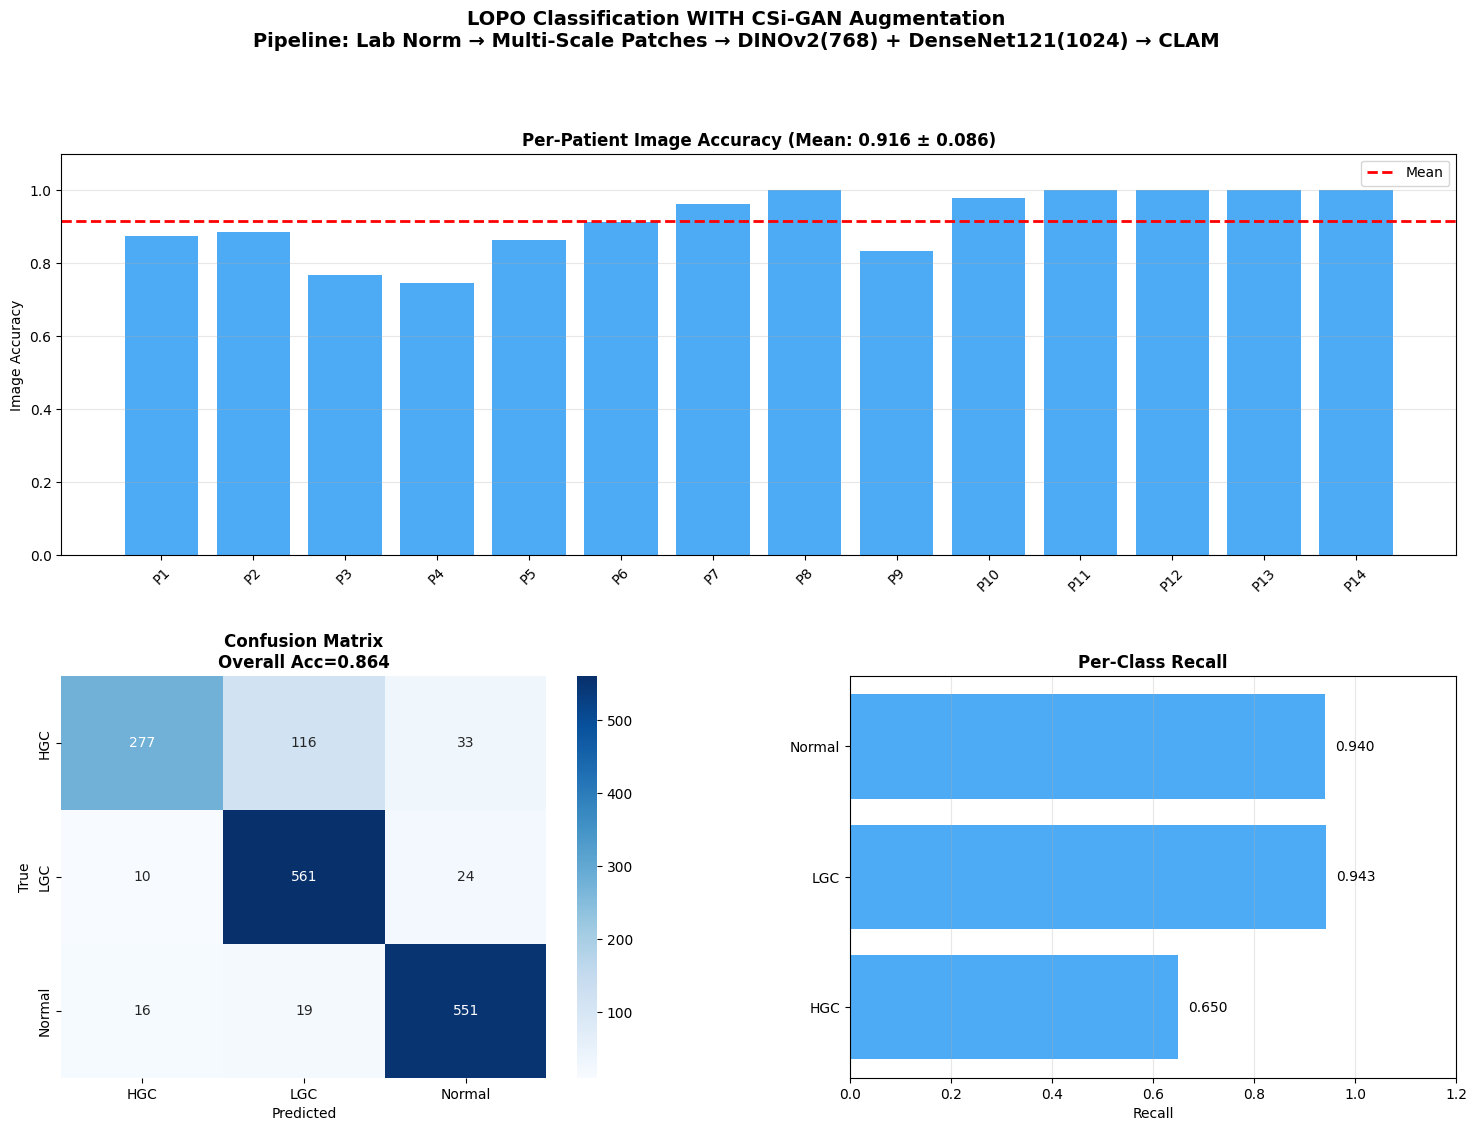

✓ Saved lopo_with_aug_results.png


In [14]:
# ============================================================
# CELL 14: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# Per-patient accuracy
ax1 = fig.add_subplot(gs[0, :])
pids = [f"P{f['patient']}" for f in results['folds']]
accs = [f['image_accuracy'] for f in results['folds']]

x = np.arange(len(pids))
bars = ax1.bar(x, accs, color='#2196F3', alpha=0.8)
ax1.set_ylabel('Image Accuracy')
ax1.set_title(
    f'Per-Patient Image Accuracy '
    f'(Mean: {results["mean_patient_accuracy"]:.3f} '
    f'± {results["std_patient_accuracy"]:.3f})',
    fontweight='bold'
)
ax1.set_xticks(x)
ax1.set_xticklabels(pids, rotation=45)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(results['mean_patient_accuracy'], color='red',
            linestyle='--', linewidth=2, label='Mean')
ax1.legend()

# Confusion matrix
ax2 = fig.add_subplot(gs[1, 0])
cm = np.array(results['overall_confusion'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title(
    f'Confusion Matrix\nOverall Acc={results["overall_image_accuracy"]:.3f}',
    fontweight='bold'
)

# Per-class recall
ax3 = fig.add_subplot(gs[1, 1])
recalls = []
for i in range(CFG.num_classes):
    total_i = cm[i].sum()
    recalls.append(cm[i, i] / max(total_i, 1))

y_pos = np.arange(CFG.num_classes)
bars = ax3.barh(y_pos, recalls, color='#2196F3', alpha=0.8)
for i in range(CFG.num_classes):
    ax3.text(recalls[i] + 0.02, i, f'{recalls[i]:.3f}', va='center', fontsize=10)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(CFG.class_names)
ax3.set_xlabel('Recall')
ax3.set_title('Per-Class Recall', fontweight='bold')
ax3.set_xlim(0, 1.2)
ax3.grid(axis='x', alpha=0.3)

fig.suptitle(
    f'LOPO Classification WITH CSi-GAN Augmentation\n'
    f'Pipeline: Lab Norm → Multi-Scale Patches → {backbone_desc} → CLAM',
    fontsize=14, fontweight='bold', y=1.00
)
plt.savefig('lopo_with_aug_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved lopo_with_aug_results.png")

In [15]:
# ============================================================
# CELL 15: EXPORT RESULTS
# ============================================================

def to_serialisable(obj):
    if isinstance(obj, (np.integer,)):   return int(obj)
    if isinstance(obj, (np.floating,)):  return float(obj)
    if isinstance(obj, np.ndarray):      return obj.tolist()
    return obj

# ── JSON ─────────────────────────────────────────────────────
summary = {
    'pipeline': f'Lab_Norm + MultiScale + {backbone_desc} + CLAM',
    'evaluation': 'LOPO',
    'augmentation': True,
    'classes': CFG.class_names,
    'n_patients': N_PATIENTS,
    'total_original_images': len(df),
    'total_augmented_images': len(aug_df),
    'results': {
        'mean_patient_acc':     results['mean_patient_accuracy'],
        'std_patient_acc':      results['std_patient_accuracy'],
        'mean_patient_bal':     results['mean_patient_balanced'],
        'std_patient_bal':      results['std_patient_balanced'],
        'overall_image_acc':    results['overall_image_accuracy'],
        'overall_balanced_acc': results['overall_balanced_accuracy'],
        'total_correct':        results['total_correct'],
        'total_images':         results['total_images'],
        'confusion_matrix':     results['overall_confusion'],
        'folds':                results['folds']
    },
    'config': {
        'patch_scales':              CFG.patch_scales,
        'max_patches_per_image':     CFG.max_patches_per_image,
        'feature_dim':               CFG.feat_dim,
        'backbone':                  backbone_desc,
        'mil_model':                 'CLAM',
        'clam_k_sample':            CFG.clam_k_sample,
        'epochs':                    CFG.epochs,
        'early_stopping_patience':   CFG.patience,
        'lr':                        CFG.lr,
        'n_ensemble':                CFG.n_ensemble,
        'class_weighted_loss':       True,
        'label_smoothing':           CFG.label_smooth,
        'use_tta':                   CFG.use_tta,
        'tta_rounds':                CFG.tta_rounds,
        'total_runtime_minutes':     total_time / 60
    }
}

with open('results_with_augmentation.json', 'w') as f:
    json.dump(summary, f, indent=2, default=to_serialisable)
print("✓ Saved results_with_augmentation.json")

# ── Per-patient CSV ──────────────────────────────────────────
rows = []
for f in results['folds']:
    rows.append({
        'patient':            f['patient'],
        'n_test_images':      f['n_test_images'],
        'accuracy':           round(f['image_accuracy'], 4),
        'balanced_accuracy':  round(f['balanced_accuracy'], 4),
        'confidence':         round(f['mean_confidence'], 4),
        'n_aug_train':        f['n_aug_train'],
    })
pd.DataFrame(rows).to_csv('fold_results_with_augmentation.csv', index=False)
print("✓ Saved fold_results_with_augmentation.csv")

# ── Classification report ────────────────────────────────────
with open('classification_report_with_aug.txt', 'w') as f:
    f.write(f"WITH CSi-GAN AUGMENTATION\n{'='*50}\n\n")
    f.write(classification_report(
        results['all_y_true'], results['all_y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))
print("✓ Saved classification_report_with_aug.txt")

print(f"\n{'='*60}")
print("  EXPERIMENT COMPLETE — WITH AUGMENTATION")
print(f"{'='*60}")
print(f"\nFinal Results:")
print(f"  Mean Patient Accuracy : {results['mean_patient_accuracy']:.4f} "
      f"± {results['std_patient_accuracy']:.4f}")
print(f"  Overall Image Accuracy: {results['overall_image_accuracy']:.4f}")
print(f"  Total Runtime         : {total_time/60:.1f} minutes")
print(f"{'='*60}\n")

✓ Saved results_with_augmentation.json
✓ Saved fold_results_with_augmentation.csv
✓ Saved classification_report_with_aug.txt

  EXPERIMENT COMPLETE — WITH AUGMENTATION

Final Results:
  Mean Patient Accuracy : 0.9164 ± 0.0863
  Overall Image Accuracy: 0.8643
  Total Runtime         : 408.4 minutes

